In [3]:

import os
import sys
import time
import traceback
from contextlib import contextmanager
from dataclasses import dataclass, asdict
from typing import Dict, Any, List

import pandas as pd

# ---------------------------
# 0) Config
# ---------------------------
PROJECT_NAME = "AI of LCA"
ECOINVENT_VERSION = "3.10.1"
SYSTEM_MODEL = "cutoff"

FILE_PATH = "/Users/ek2517/Documents/GitHub/ARIA/examples/Data_inputs_battery_example.xlsx"
USECOLS = "A:C"
NROWS = 18

SKIP_EXCEL_EDIT = os.getenv("ARIA_SKIP_EXCEL_EDIT", "0") == "1"
SUMMARY_CSV = "aria_case_study_timings.csv"
CASE_LABEL = "Battery production"


# ---------------------------
# 1) Small timing utilities
# ---------------------------
@dataclass
class StepResult:
    step: str
    seconds: float
    notes: str = ""

@contextmanager
def timer(step_name: str, results: List[StepResult], notes: str = ""):
    start = time.perf_counter()
    try:
        yield
    except Exception:
        # Record the time up to the error and re-raise
        elapsed = time.perf_counter() - start
        results.append(StepResult(step=step_name, seconds=elapsed, notes="ERROR: " + traceback.format_exc()))
        raise
    else:
        elapsed = time.perf_counter() - start
        results.append(StepResult(step=step_name, seconds=elapsed, notes=notes))


def seconds_str(s: float) -> str:
    return f"{s:.3f}"


# ---------------------------
# 2) Imports from ARIA / Brightway
# ---------------------------
from ARIA.project_setup import setup_brightway_project
from ARIA.data_handling import open_excel_with_applescript, read_and_clean_excel
from ARIA.openai_client import create_openai_client
from ARIA.search_workflow import process_dataframe
from ARIA.ecoinvent_processing import process_ecoinvent_dataframe
from ARIA.impact_assessment import run_impact_assessment
default_api_key = os.getenv("OPENAI_API_KEY")
if not default_api_key:
    raise EnvironmentError("OPENAI_API_KEY not found in environment variables.")
with timer("Create OpenAI client", timings):
    client = create_openai_client(default_api_key)


# ---------------------------
# 3) Run the pipeline with timings
# ---------------------------
timings: List[StepResult] = []

# 3.1 Brightway + ecoinvent setup
with timer("Project & database setup", timings, notes=f"{ECOINVENT_VERSION} - {SYSTEM_MODEL}"):
    ecoinvent_db = setup_brightway_project(PROJECT_NAME, ECOINVENT_VERSION, SYSTEM_MODEL)
    print(f"ecoinvent database '{ECOINVENT_VERSION} - {SYSTEM_MODEL}' loaded into project: {PROJECT_NAME}")

# 3.2 Optional Excel open + user editing pause
if not SKIP_EXCEL_EDIT:
    with timer("Open Excel (AppleScript)", timings):
        open_excel_with_applescript(FILE_PATH)
    # Measure the human editing pause separately (useful to report but often excluded)
    print("\n>>> After editing and saving the Excel file, press Enter to continue...")
    with timer("User editing pause", timings, notes="Human-in-the-loop delay"):
        input()
else:
    print("Skipping Excel open + editing pause (ARIA_SKIP_EXCEL_EDIT=1).")

# 3.3 Read & clean foreground data
with timer("Read & clean Excel", timings, notes=f"usecols={USECOLS}, nrows={NROWS}"):
    df_in = read_and_clean_excel(FILE_PATH, usecols=USECOLS, nrows=NROWS)
    print("\nImported data:")
    print(df_in)

# 3.4 Create LLM client
with timer("Create OpenAI client", timings):
    client = create_openai_client(default_api_key)

# 3.5 LLM-assisted database search + refinement
user_message = (
    "I am performing a life cycle assessment of a lithium-ion battery. "
    "You are a domain expert choosing datasets to represent inventory flows."
)
with timer("LLM-assisted mapping (search + refinement)", timings, notes="process_dataframe"):
    df_mapped = process_dataframe(
        df_in,
        db=ecoinvent_db,
        client=client,
        user_message=user_message,
        locations=["GLO", "RoW"],
        verbose=True  # Set to False if you don’t want dataset names printed
    )
    print("\nMapped dataframe:")
    print(df_mapped.to_string(index=False))

# 3.6 Post-processing / normalization for ecoinvent
with timer("Ecoinvent post-processing", timings, notes="process_ecoinvent_dataframe"):
    df_processed = process_ecoinvent_dataframe(df_mapped)
    print("\nPost-processed dataframe:")
    print(df_processed.to_string(index=False))

# 3.7 Impact assessment
LCIA_METHODS = [
    ('EF v3.1', 'climate change', 'global warming potential (GWP100)'),
    ('EF v3.1', 'material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserves)'),
    ('EF v3.1', 'water use', 'user deprivation potential (deprivation-weighted water consumption)'),
    ('EF v3.1', 'acidification', 'accumulated exceedance (AE)'),
    ('EF v3.1', 'ecotoxicity: freshwater', 'comparative toxic unit for ecosystems (CTUe)'),
    ('EF v3.1', 'human toxicity: carcinogenic', 'comparative toxic unit for human (CTUh)'),
    ('EF v3.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
    ('EF v3.1', 'particulate matter formation', 'impact on human health'),
    ('EF v3.1', 'photochemical oxidant formation: human health', 'tropospheric ozone concentration increase'),
]

with timer("Impact assessment", timings, notes="run_impact_assessment"):
    df_impacts = run_impact_assessment(df_processed, LCIA_METHODS)
    print("\nImpact results (head):")
    print(df_impacts.head().to_string(index=False))

# ---------------------------
# 4) Summaries & export
# ---------------------------
# Calculate per-flow mapping time (based on rows processed)
n_flows = len(df_in)
map_step = next((t for t in timings if t.step.startswith("LLM-assisted mapping")), None)
per_flow_sec = (map_step.seconds / n_flows) if (map_step and n_flows > 0) else float("nan")

# Compose a clean summary table
summary_rows: List[Dict[str, Any]] = []
total_runtime = 0.0
for t in timings:
    # Exclude the human editing pause from the "automated total" but keep it in the table
    if t.step != "User editing pause":
        total_runtime += t.seconds
    summary_rows.append({
        "case_label": CASE_LABEL,
        "step": t.step,
        "seconds": round(t.seconds, 3),
        "notes": t.notes
    })

# Append convenience aggregates
summary_rows.append({
    "case_label": CASE_LABEL,
    "step": "Per-flow mapping (derived)",
    "seconds": round(per_flow_sec, 3),
    "notes": f"Flows={n_flows}"
})
summary_rows.append({
    "case_label": CASE_LABEL,
    "step": "Automated total (excl. human pause)",
    "seconds": round(total_runtime, 3),
    "notes": ""
})

summary_df = pd.DataFrame(summary_rows, columns=["case_label", "step", "seconds", "notes"])
print("\n=== Timing Summary ===")
print(summary_df.to_string(index=False))

summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved timing summary to: {os.path.abspath(SUMMARY_CSV)}")


Biosphere database already present!!! No setup is needed
'ecoinvent-3.10.1-cutoff' is already present in the project 'AI of LCA'.
ecoinvent database '3.10.1 - cutoff' loaded into project: AI of LCA

>>> After editing and saving the Excel file, press Enter to continue...



Imported data:
                   Input/output     In/out Units
0              Sodium hydroxide   1.232821    kg
1                Primary copper   0.284312    kg
2                Cobalt sulfate   0.202911    kg
3             Manganese sulfate   0.197711    kg
4                Nickel sulfate   1.620383    kg
5                      Graphite   0.902401    kg
6             Lithium hydroxide   0.313384    kg
7            Ethylene carbonate   0.313225    kg
8             Primary aluminium   0.162282    kg
9                  Carbon black   0.070724    kg
10           Polyvinyl fluoride   0.090283    kg
11  lithium hexafluorophosphate   0.056125    kg
12                Polypropylene   0.030897    kg
13                 Polyethylene   0.006803    kg
14   Polyethylene terephthalate   0.007937    kg
15                  Electricity  60.000000   kWh

Processing row 1: sodium hydroxide
Excluding 146 filtered results
Excluding 135 filtered results
LLM selected: - chlor-alkali electrolysis, diaphragm 

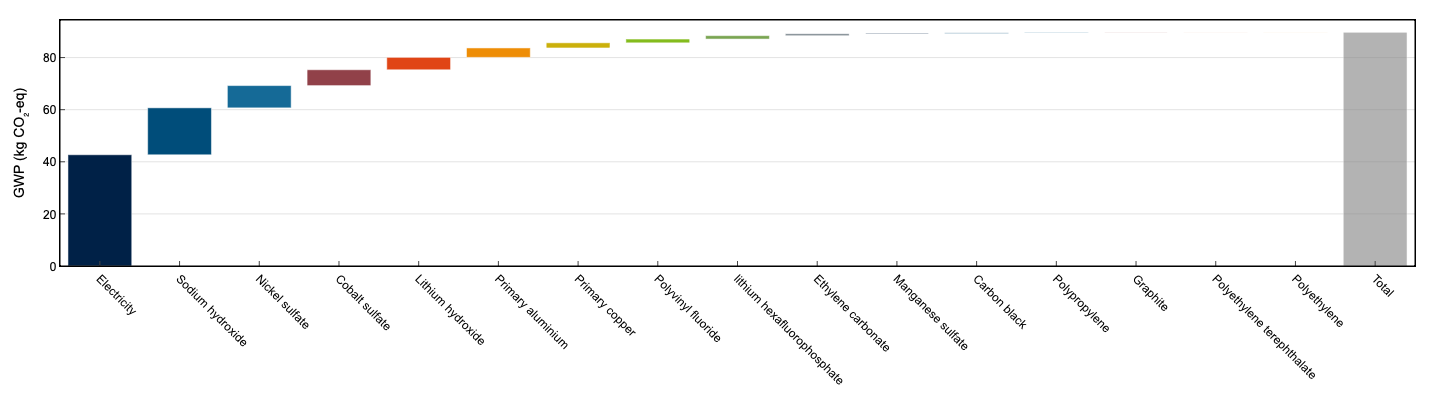

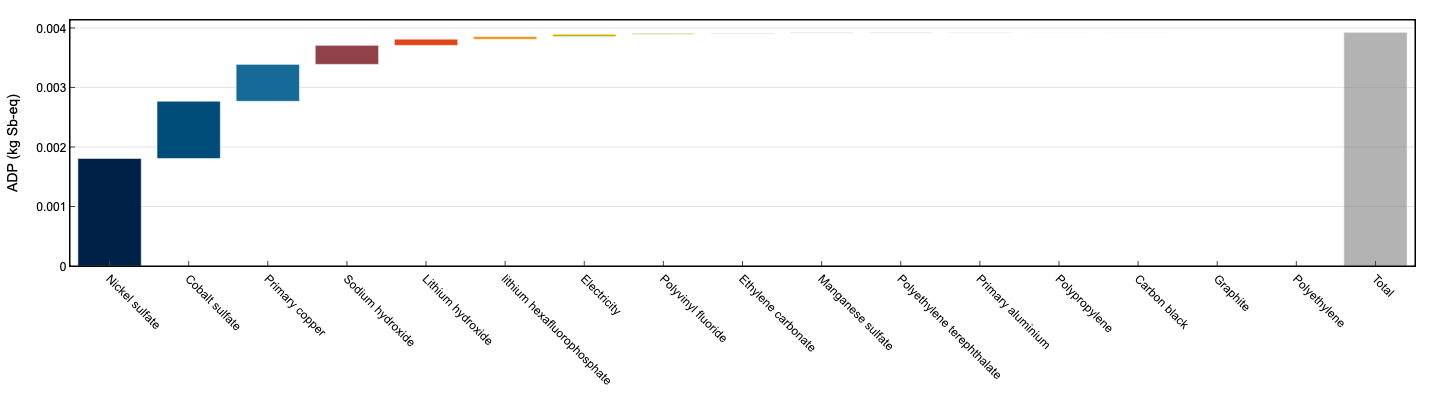

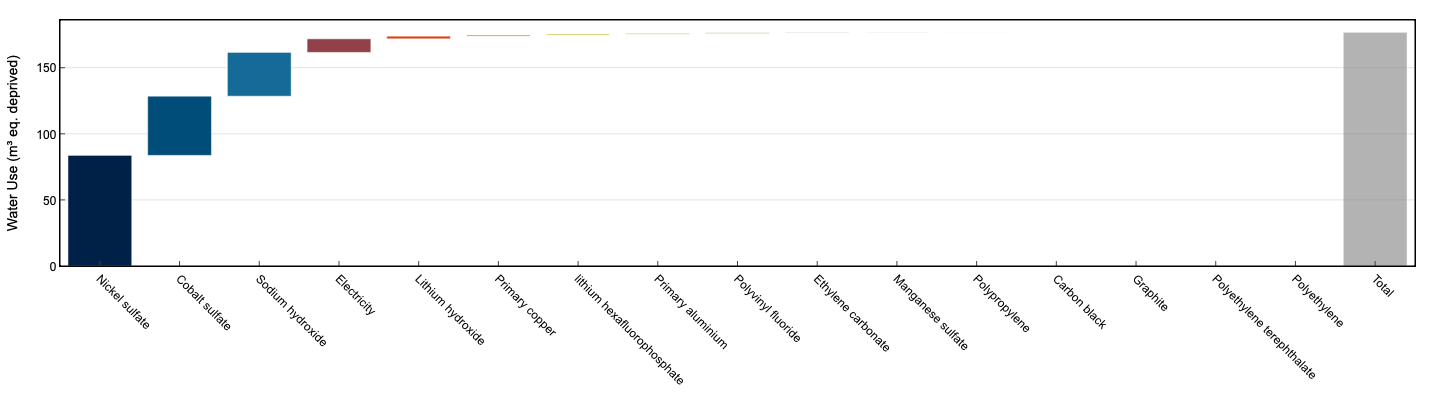

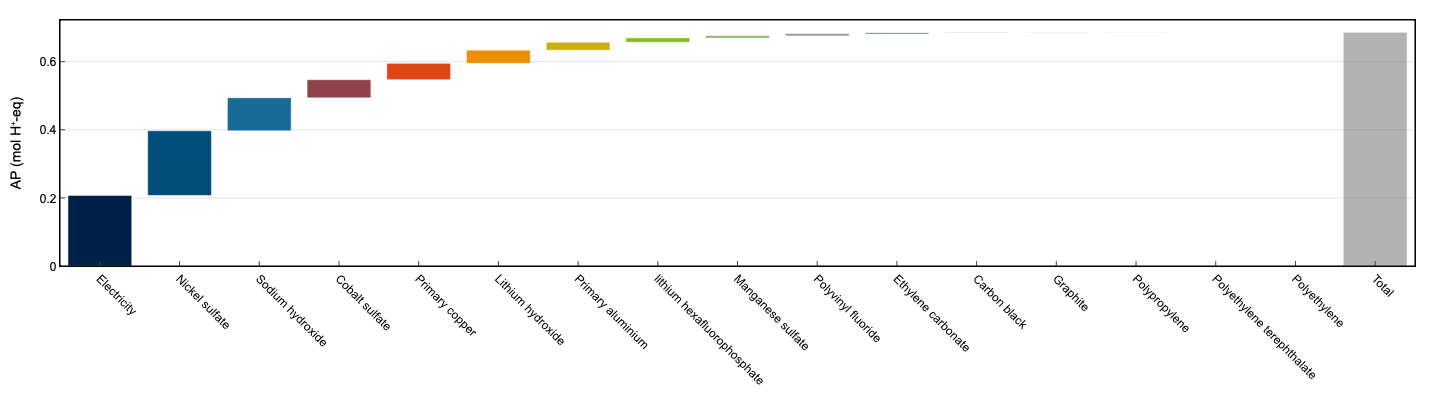

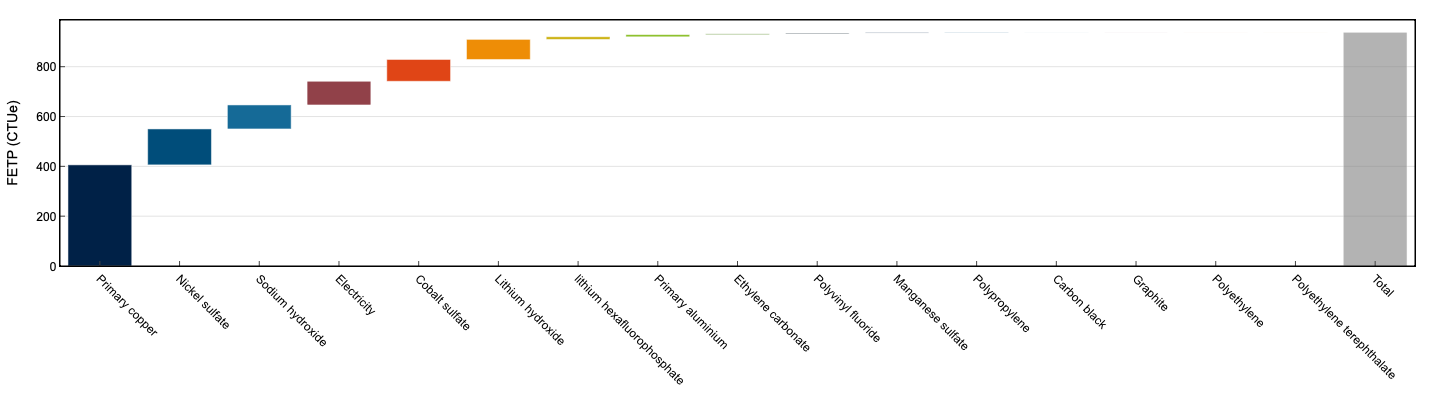

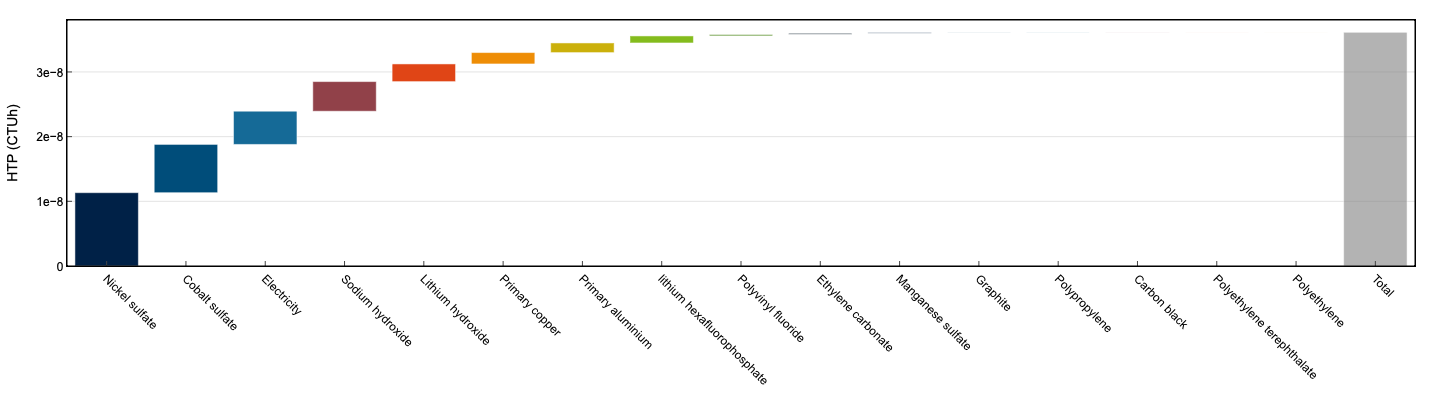

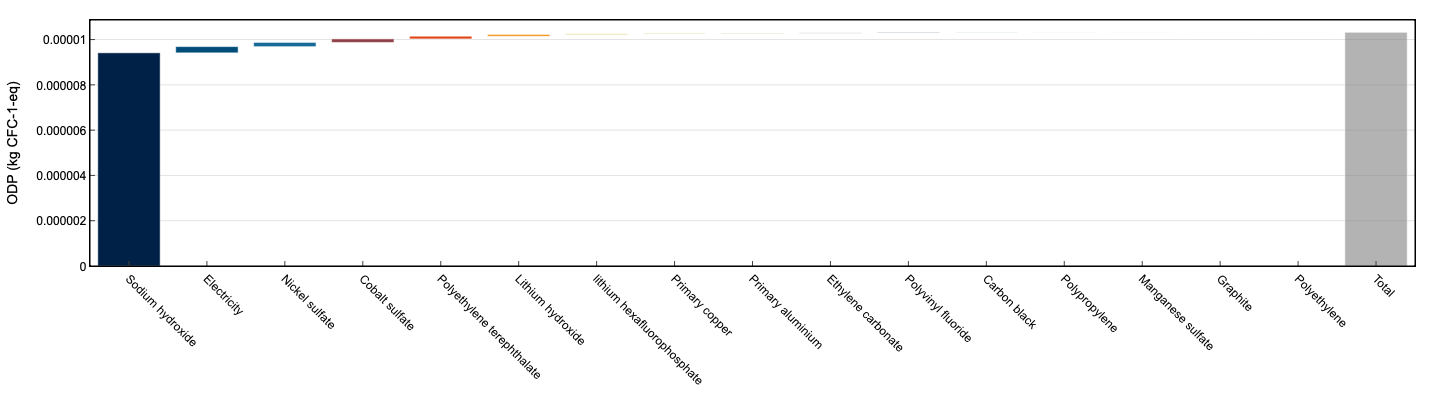

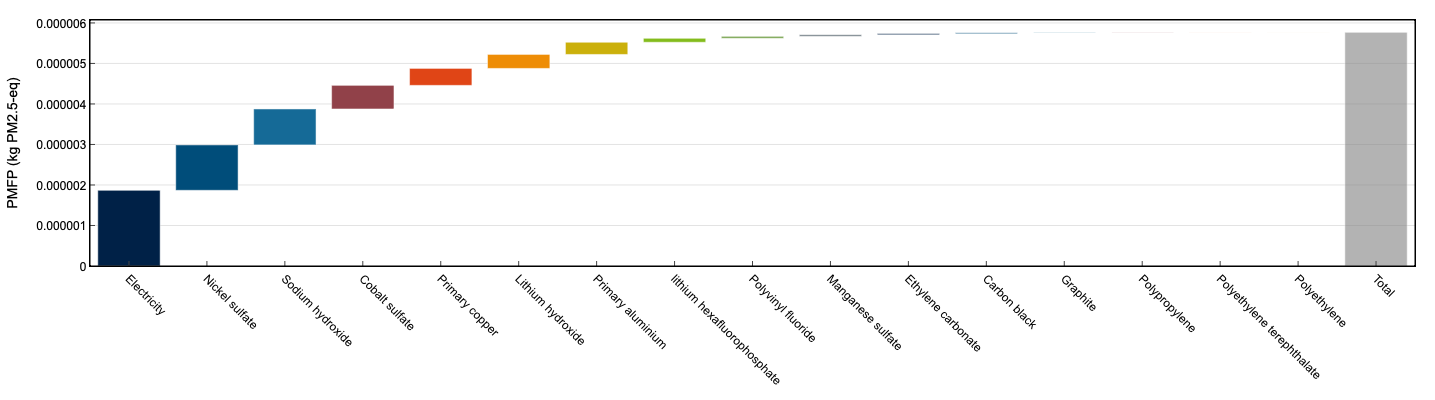

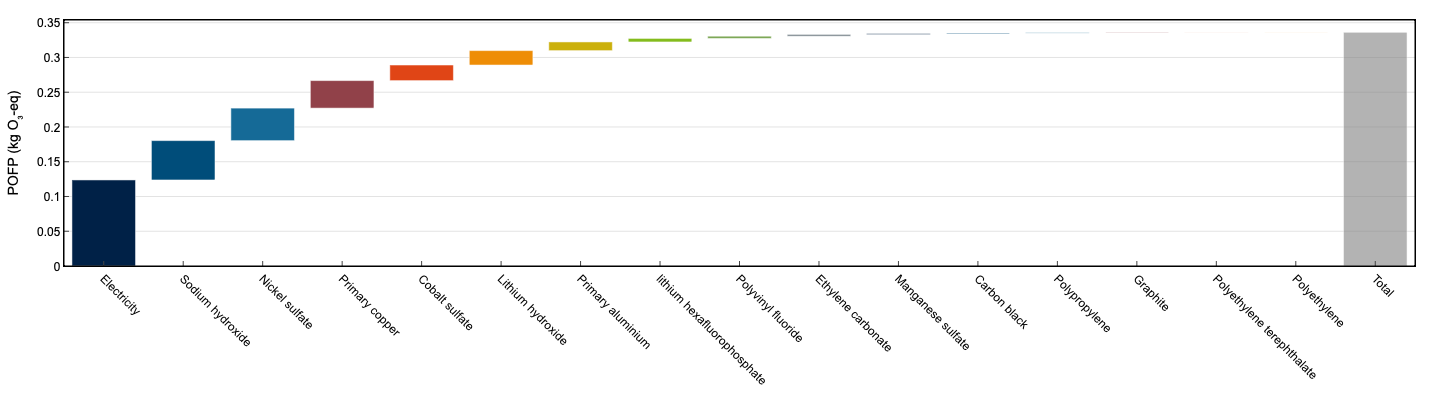

In [4]:
from ARIA.plot_lcia import plot_lcia_waterfall_charts

# Just call the function:
plot_lcia_waterfall_charts(df_processed)

#Alternatively, we can export the dataframe to excel for further plotting
#processed_df.to_excel("output.xlsx", index=False)